#================================================
# Step 1: Import necessary Libraries
#=================================================


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# setp 2 : Display all columns
pd.set_option('display.max_columns', None)

#======================================================
#Step 3: Load the Dataset
#======================================================

In [26]:
#setp 3 :Replace the filename if needed
df= pd.read_csv("Telco-Customer-Churn.csv")


In [27]:
#setp 4 : Display first 10 rows
print("First 10 rows:")
display(df.head(10))

First 10 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [28]:
# Step 5 : Display Column Names
print("\n Column Names:")
print(df.columns.tolist())


 Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [29]:
# Step 6 : Display Data Types
print("\n Data Types:")
print(df.dtypes)


 Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


#==========================================================
# Data Preprocessing Phase
#===========================================================

#step 7: Convert TotalCharges to numeric

In [41]:
# Errors= 'coerce' converts invalid values to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [42]:
#step 8: Remove rows with missing values
df = df.dropna()

In [32]:
# Step 9: Remove customerID column
df = df.drop("customerID", axis=1)

In [43]:
# step 10 Convert Churn to binary values
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0
})

In [44]:
#step 11 : Convert categorical variables to dummy variables
telecom_cust_dummies = pd.get_dummies(
    df,
    drop_first = True
)

In [45]:
#Display Results

print("\n Shape after preprocessing:")
print(telecom_cust_dummies.shape)

print("\n First 5 rows of telecom_cust_summies:")
display(telecom_cust_dummies.head())


 Shape after preprocessing:
(7032, 31)

 First 5 rows of telecom_cust_summies:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_1
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True


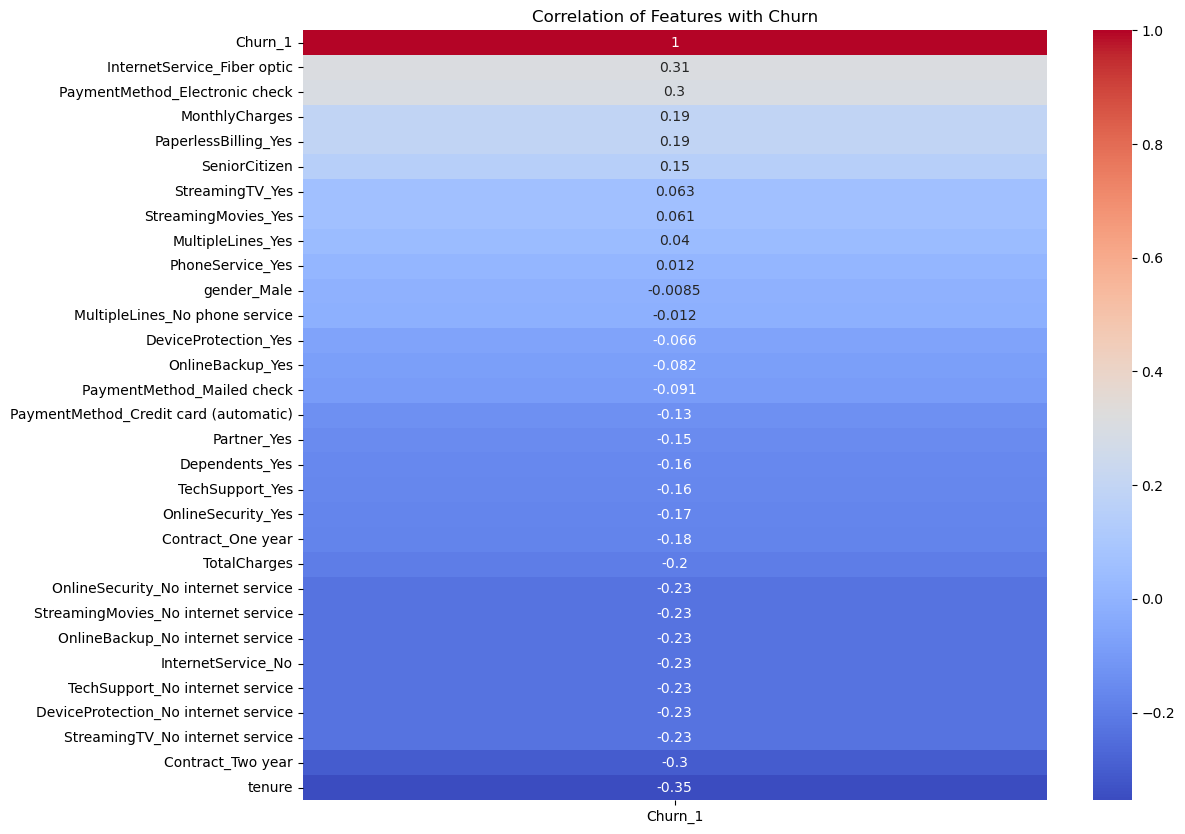

In [49]:
# step 12 : Correlation Plot

plt.figure(figsize=(12, 10))
correlation = telecom_cust_dummies.corr()

sns.heatmap(
    correlation[["Churn_1"]].sort_values(by="Churn_1", ascending=False),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation of Features with Churn')
plt.show()

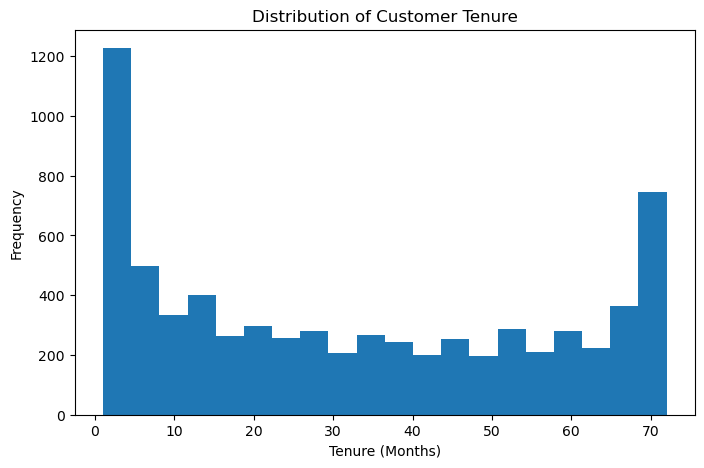

In [50]:
# Step 13: Histogram of Tenure

plt.figure(figsize=(8,5))
plt.hist(df['tenure'] , bins=20)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel('Frequency')
plt.show()

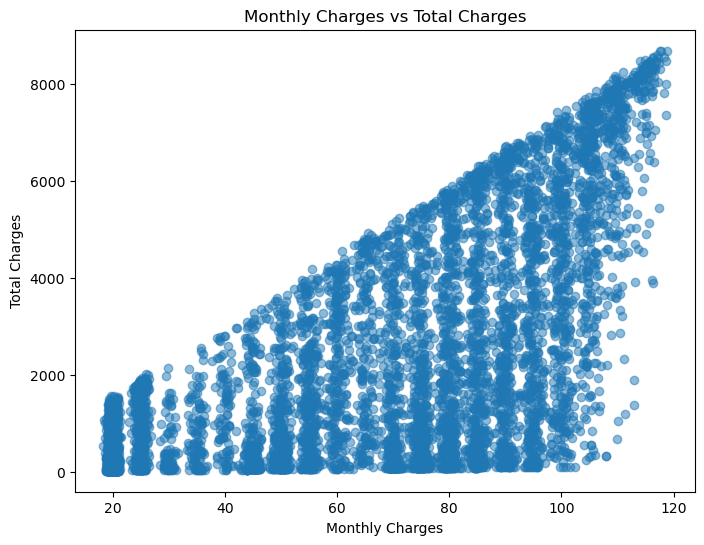

In [51]:
# step 14 Scatter Plot: Monthly Charges vs Total Chages

plt.figure(figsize= (8,6))
plt.scatter(df['MonthlyCharges'], df['TotalCharges'], alpha=0.5)
plt.title("Monthly Charges vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

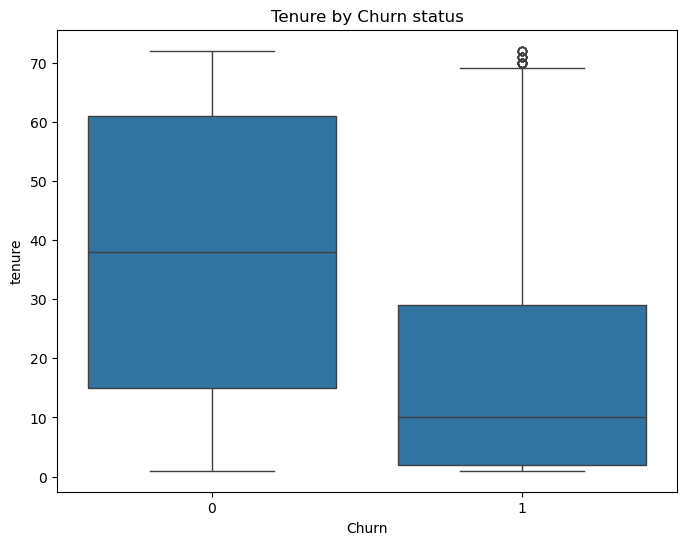

In [53]:
#step 15: Cox Plot: Tenure by Churn Status
plt.figure(figsize=(8,6))

sns.boxplot(
     x="Churn",
     y="tenure",
     data=df
)

plt.title('Tenure by Churn status')
plt.show()

#=================================================================
#Preparations For ML Training
#=================================================================

In [59]:
# step 16: Scale Variables Using Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

X= telecom_cust_dummies.drop('Churn_1', axis=1)
y= telecom_cust_dummies['Churn_1']

scaler = MinMaxScaler()
X_scaled= scaler.fit_transform(X)

In [62]:
# spep 17 Split Data into Training and Test Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size =0.25,
    random_state = 42
)

print(X_train.shape)
print(X_test.shape)

(5274, 30)
(1758, 30)


#==================================================================
# Logistic Regression Model
#==================================================================


In [63]:
#step 18: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [64]:
#step 19 Make Predictions
log_predictions = log_model.predict(X_test)


In [65]:
#step 20 Accuracy Score
from sklearn.metrics import accuracy_score
log_accuracy = accuracy_score(y_test, log_predictions)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7912400455062572


#==================================================================
# Random Forest Model
#==================================================================


In [67]:
# step 21 Craete Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(
    n_estimators = 2000,
    oob_score = True,
    max_features='sqrt',
    max_leaf_nodes = 50,
    bootstrap = True,
    random_state=42,
    n_jobs= -1
)

In [68]:
# step 22 Fit the Model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [69]:
#step 23 Make Predictions
rf_predictions = rf_model.predict(X_test)

In [71]:
#Step 24 Accuracy Score
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7935153583617748


In [72]:
# step 25 OOB Error Estimation
oob_error = 1 - rf_model.oob_score_

print("OOB Score:", rf_model.oob_score_)
print("OOB Error:", oob_error)

OOB Score: 0.807356844899507
OOB Error: 0.192643155100493


In [73]:
print(f""" The OOB score is {rf_model.oob_score_:.4f}.
           This means the model correctly classifies  approximately
           {rf_model.oob_score_*100:.2f}% of unseen observations.

           The OOB errror is {oob_error:.4f}, indicating the proportion
           of observations likely to be misclassified on unseen data.
           A lower OOB error Suggest better generalisation.
           """)

 The OOB score is 0.8074.
           This means the model correctly classifies  approximately
           80.74% of unseen observations.

           The OOB errror is 0.1926, indicating the proportion
           of observations likely to be misclassified on unseen data.
           A lower OOB error Suggest better generalisation.
           


#==================================================================
# Enhanced Model Evalution
#==================================================================

In [76]:
# step 26: Confusion Metrices

from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(y_test, log_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)

print("Logistics Regression Confusion Matrix")
print(log_cm)

print("\n Random Forest Confusion Matrix")
print(rf_cm)

Logistics Regression Confusion Matrix
[[1154  146]
 [ 221  237]]

 Random Forest Confusion Matrix
[[1187  113]
 [ 250  208]]


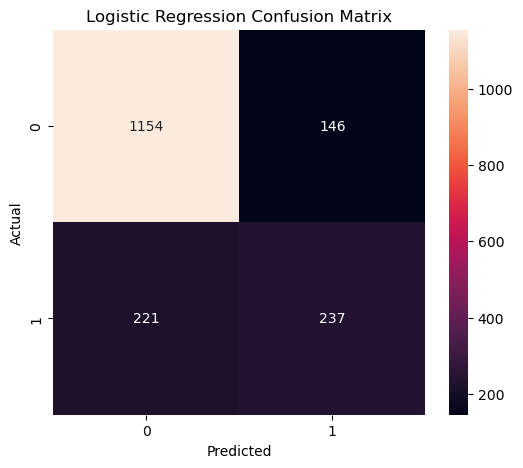

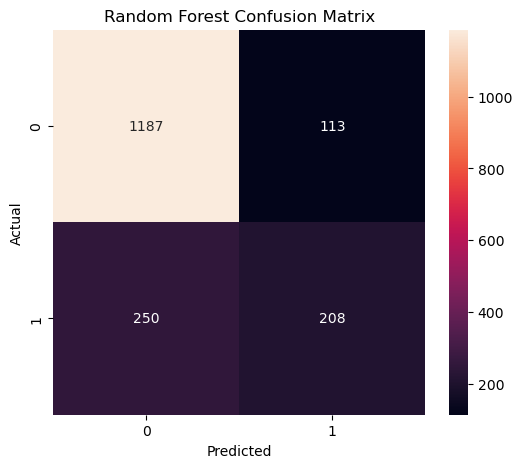

In [78]:
plt.figure(figsize=(6,5))
sns.heatmap(log_cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [79]:
#step 27 Precision and Recall

from sklearn.metrics import precision_score, recall_score

#logistic regression
log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)

#random forst
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)


print("Logistic regression")
print("Precision:", log_precision)
print("Recall:", log_recall)

print("\n Random Forest")
print("Precision:", rf_precision)
print("Recall:", rf_recall)

Logistic regression
Precision: 0.618798955613577
Recall: 0.517467248908297

 Random Forest
Precision: 0.6479750778816199
Recall: 0.45414847161572053


#Step 28 Discussion On Results
The confusion matrices provide detailed insight into how well each model classified customers as churners or non_churners

Logistics Regression Model: 
The logistic regression model correctly identified 1157 non churning cutomers(True Negatives) and 237 churning customers (True positives). However, it incorrectly classified 146 non-churning customers as churners (False Positive) and failed to identify 221 churning customers (False negatives)

The relatively high number of true negatives indicates that the model performs well at recognising customers who are likely to remain withthe company. Additionally, the model successfully identified over half of the customers who actully chruned. The false negatives are important because these represent customers who left the service without being detected by the model, resulting in missed retention oppoertunities.


Random Forest Model
The Random Forest model correctly classified 1187 non churning customers (True Negatives) and 208 churning customers (True Positive) . It produced 113 false positives and 250 false negatives.

Compared with logisitc regression, Random Forest was better at idenitifying customers who would stay with the company, as shown by its highter number of true negatives and lower number of false positives. However it misses more actual churners resulting in a hegher number of false negatives 


Precision and recall analysis
Precision measures how many customers predicted to churn actully churned, while recall measures how many actual churners were correctly identified

Using the confusion matrix values:

Logistic Regression
1) precision = 237/(237 + 146) = 0.619
2) Recall = 237/ (237 + 221) = 0.517

Random Forest
1) precision = 208/ (208 ++ 113) = 0.648
2) Recall = 208/ (208 + 250) = 0.454

The random forest model achieved slightly higher precision, meaning that when it predicts a customer will churn, it is more likey to be correct. However, its recall is lower than logistic regression, indicating that it misses more customers who actully churn.

#step 29 Comparision of logistic regression and Random Forest zModels
The Logistic Regression and Random Forest models performed similarly in terms of overall classification performance,
but they exibited diffrent strengths when evaluated using peecision, recall and the cofusion matrix.

The Random Forest model achieved a slightly higher precision(64.8%) than the logistic Regression Model (61.9%).
This indicates that when Random Forest Predicts a customer will churn it is more likely to be correct. 
In addition Random Forest produced fewer false positives(113 compared to 146)
meaning it generated fewer unnecessary retention efforts aimed at customers who were not actually at risk of leaving

However the Logistic Regression model achieved a higher recall (51.7%) than the Random Forest model (45.4%). 
This means that Logistic Regression was able to identify a larger proportion of customers who actully churned. 
It also resulted in fewer false negatives (221 comapred to 250), which is imporatnt because false negatives represent customers who churn without being detected by the model.

In conclusion while Random Forest is better at avoiding incorrect churn predictions, Logistic Regression is more effective at finding customers who are likely to leave. Therefore, Logistic Regression provieds greater business value for customer retention efforts and is the preffred model for this churn prediction problem.
    
     
